<a href="https://colab.research.google.com/github/shefiramarizcha62-sudo/TA/blob/main/notebooks/Fine_Tuning_Best_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import gc
import time
import random
import warnings

import numpy as np
import pandas as pd

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# CELL 3 — PROJECT PATH


from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08"

DATA_DIR = os.path.join(PROJECT_DIR, "dataset")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
LOG_DIR = os.path.join(PROJECT_DIR, "logs")

print("=" * 60)
print("PROJECT PATH")
print("=" * 60)

print(f"Project directory : {PROJECT_DIR}")
print(f"Dataset directory : {DATA_DIR}")
print(f"Result directory  : {RESULT_DIR}")
print(f"Log directory     : {LOG_DIR}")

print("\nFolder existing akan digunakan.")

Mounted at /content/drive
PROJECT PATH
Project directory : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08
Dataset directory : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/dataset
Result directory  : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results
Log directory     : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/logs

Folder existing akan digunakan.


In [4]:
# ============================================================
# CELL 4 — LOAD FIXED DATA SPLITS
# ============================================================

TRAIN_PATH = os.path.join(
    DATA_DIR,
    "splits",
    "train_split.csv"
)

VAL_PATH = os.path.join(
    DATA_DIR,
    "splits",
    "validation_split.csv"
)

TEST_PATH = os.path.join(
    DATA_DIR,
    "splits",
    "test_split.csv"
)

print("=" * 60)
print("LOADING FIXED DATA SPLITS")
print("=" * 60)

print(f"Train      : {TRAIN_PATH}")
print(f"Validation : {VAL_PATH}")
print(f"Test       : {TEST_PATH}")

# ============================================================
# LOAD CSV
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("\nJumlah data:")
print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")

print(
    f"Total      : "
    f"{len(train_df) + len(val_df) + len(test_df):,}"
)

print("\nKolom train:")
print(train_df.columns.tolist())

LOADING FIXED DATA SPLITS
Train      : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/dataset/splits/train_split.csv
Validation : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/dataset/splits/validation_split.csv
Test       : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/dataset/splits/test_split.csv

Jumlah data:
Train      : 3,052
Validation : 381
Test       : 382
Total      : 3,815

Kolom train:
['Komentar_preprocessed', 'Kode Label', 'label']


In [5]:
# ============================================================
# CELL 5 — LABEL MAPPING & FIXED SPLIT CHECK
# ============================================================

SEED = 42

# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# ============================================================
# LABEL MAPPING
# ============================================================

label2id = {
    "C0": 0,
    "C1": 1,
    "C2": 2,
    "C3": 3,
    "C4": 4
}

id2label = {
    0: "C0",
    1: "C1",
    2: "C2",
    3: "C3",
    4: "C4"
}

# ============================================================
# PASTIKAN LABEL SUDAH NUMERIK
# ============================================================

# Jika CSV fixed split sudah memiliki kolom "label",
# gunakan langsung tanpa melakukan split ulang.

if "label" not in train_df.columns:
    raise ValueError(
        "Kolom 'label' tidak ditemukan pada train_split.csv."
    )

if "label" not in val_df.columns:
    raise ValueError(
        "Kolom 'label' tidak ditemukan pada validation_split.csv."
    )

if "label" not in test_df.columns:
    raise ValueError(
        "Kolom 'label' tidak ditemukan pada test_split.csv."
    )

# ============================================================
# CEK NILAI LABEL
# ============================================================

expected_labels = {0, 1, 2, 3, 4}

for name, split_df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:

    actual_labels = set(
        split_df["label"].dropna().astype(int).unique()
    )

    if actual_labels != expected_labels:
        raise ValueError(
            f"Label pada {name} tidak sesuai. "
            f"Ditemukan: {sorted(actual_labels)}"
        )

# ============================================================
# FINAL CHECK
# ============================================================

print("=" * 60)
print("FIXED SPLIT & LABEL CHECK")
print("=" * 60)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")
print(
    f"Total      : "
    f"{len(train_df) + len(val_df) + len(test_df):,}"
)

print("\nLabel mapping:")
for label, idx in label2id.items():
    print(f"{label} -> {idx}")

print("\nDistribusi label TRAIN:")
print(train_df["label"].value_counts().sort_index())

print("\nDistribusi label VALIDATION:")
print(val_df["label"].value_counts().sort_index())

print("\nDistribusi label TEST:")
print(test_df["label"].value_counts().sort_index())

print("\nFixed split digunakan tanpa melakukan split ulang.")

FIXED SPLIT & LABEL CHECK
Train      : 3,052
Validation : 381
Test       : 382
Total      : 3,815

Label mapping:
C0 -> 0
C1 -> 1
C2 -> 2
C3 -> 3
C4 -> 4

Distribusi label TRAIN:
label
0    610
1    611
2    610
3    610
4    611
Name: count, dtype: int64

Distribusi label VALIDATION:
label
0    76
1    76
2    77
3    76
4    76
Name: count, dtype: int64

Distribusi label TEST:
label
0    77
1    76
2    76
3    77
4    76
Name: count, dtype: int64

Fixed split digunakan tanpa melakukan split ulang.


In [6]:
TEXT_COL = "Komentar_preprocessed"

print(f"Text column : {TEXT_COL}")

Text column : Komentar_preprocessed


In [7]:
# ============================================================
# CELL 13 — CREATE HUGGING FACE DATASETS
# ============================================================

from datasets import Dataset

print("=" * 60)
print("CREATING HUGGING FACE DATASETS")
print("=" * 60)

# Gunakan hanya kolom yang dibutuhkan model
train_hf = Dataset.from_pandas(
    train_df[[TEXT_COL, "label"]],
    preserve_index=False
)

val_hf = Dataset.from_pandas(
    val_df[[TEXT_COL, "label"]],
    preserve_index=False
)

test_hf = Dataset.from_pandas(
    test_df[[TEXT_COL, "label"]],
    preserve_index=False
)

print(f"Train      : {len(train_hf):,}")
print(f"Validation : {len(val_hf):,}")
print(f"Test       : {len(test_hf):,}")

print("\nContoh train:")
print(train_hf[0])

print("\nDataset Hugging Face berhasil dibuat.")

CREATING HUGGING FACE DATASETS
Train      : 3,052
Validation : 381
Test       : 382

Contoh train:
{'Komentar_preprocessed': 'wah sudah parah kesal ini roman2 nya bang fery sampai gemeteran cuy bicara nya', 'label': 0}

Dataset Hugging Face berhasil dibuat.


In [9]:
# ============================================================
# CELL 7 — FINAL MODEL CONFIGURATION
# IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

FINAL_MODEL = "IndoBERT Large P2"
FINAL_MAX_LENGTH = 256

MODEL_CONFIGS = {
    FINAL_MODEL: {
        "model_name": "indobenchmark/indobert-large-p2",
        "batch_size": 4,
    },
}

NUM_LABELS = 5

print("=" * 60)
print("FINAL MODEL CONFIGURATION")
print("=" * 60)

print(f"\nModel      : {FINAL_MODEL}")
print(f"Checkpoint : {MODEL_CONFIGS[FINAL_MODEL]['model_name']}")
print(f"Batch size : {MODEL_CONFIGS[FINAL_MODEL]['batch_size']}")
print(f"MAX_LENGTH : {FINAL_MAX_LENGTH}")
print(f"Num labels : {NUM_LABELS}")

print("\nStatus : FINAL CONFIGURATION")

FINAL MODEL CONFIGURATION

Model      : IndoBERT Large P2
Checkpoint : indobenchmark/indobert-large-p2
Batch size : 4
MAX_LENGTH : 256
Num labels : 5

Status : FINAL CONFIGURATION


In [10]:
# ============================================================
# CELL 8 — TOKENIZATION FUNCTION
# FINAL: IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

def tokenize_datasets(
    train_dataset,
    validation_dataset,
    test_dataset,
    tokenizer,
    max_length
):
    """
    Tokenisasi train, validation, dan test.

    MAX_LENGTH ditetapkan untuk final model:
    IndoBERT Large P2 + MAX_LENGTH 256.

    Dynamic padding dilakukan kemudian oleh
    DataCollatorWithPadding.
    """

    def tokenize_function(examples):
        return tokenizer(
            examples[TEXT_COL],
            truncation=True,
            max_length=max_length,
            padding=False
        )

    tokenized_train = train_dataset.map(
        tokenize_function,
        batched=True,
        desc=f"Tokenizing train | max_length={max_length}"
    )

    tokenized_validation = validation_dataset.map(
        tokenize_function,
        batched=True,
        desc=f"Tokenizing validation | max_length={max_length}"
    )

    tokenized_test = test_dataset.map(
        tokenize_function,
        batched=True,
        desc=f"Tokenizing test | max_length={max_length}"
    )

    # Hapus kolom teks setelah tokenisasi
    tokenized_train = tokenized_train.remove_columns(
        [TEXT_COL]
    )

    tokenized_validation = tokenized_validation.remove_columns(
        [TEXT_COL]
    )

    tokenized_test = tokenized_test.remove_columns(
        [TEXT_COL]
    )

    return (
        tokenized_train,
        tokenized_validation,
        tokenized_test
    )


print("=" * 60)
print("TOKENIZATION FUNCTION READY")
print("=" * 60)

print("Model      :", FINAL_MODEL)
print("MAX_LENGTH :", FINAL_MAX_LENGTH)
print("Padding    : Dynamic padding via DataCollatorWithPadding")
print("Status     : READY")

TOKENIZATION FUNCTION READY
Model      : IndoBERT Large P2
MAX_LENGTH : 256
Padding    : Dynamic padding via DataCollatorWithPadding
Status     : READY


In [11]:
# ============================================================
# CELL 9 — DATA COLLATOR
# ============================================================

from transformers import DataCollatorWithPadding

def create_data_collator(tokenizer):
    """
    Membuat data collator dengan dynamic padding
    berdasarkan tokenizer model yang sedang digunakan.
    """

    return DataCollatorWithPadding(
        tokenizer=tokenizer,
        padding=True
    )


print("=" * 60)
print("DATA COLLATOR FUNCTION READY")
print("=" * 60)
print("Collator : DataCollatorWithPadding")
print("Padding  : Dynamic padding per batch")
print("Status   : READY")

DATA COLLATOR FUNCTION READY
Collator : DataCollatorWithPadding
Padding  : Dynamic padding per batch
Status   : READY


In [12]:
# ============================================================
# CELL 10 — EVALUATION METRICS
# ============================================================

def compute_metrics(eval_pred):
    """
    Menghitung metrik evaluasi untuk klasifikasi C0-C4.

    Macro-F1 digunakan sebagai metrik utama karena
    setiap kelas perlu diperlakukan secara setara.
    """

    logits, labels = eval_pred

    # Prediksi kelas berdasarkan nilai logit tertinggi
    predictions = np.argmax(logits, axis=-1)

    # Precision, Recall, F1 per kelas lalu dirata-ratakan secara macro
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1
    }


print("=" * 60)
print("EVALUATION METRICS READY")
print("=" * 60)

print("Metrics:")
print("- Accuracy")
print("- Macro Precision")
print("- Macro Recall")
print("- Macro F1")

print("\nPrimary metric : Macro-F1")
print("Status         : READY")

EVALUATION METRICS READY
Metrics:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1

Primary metric : Macro-F1
Status         : READY


In [21]:
# ============================================================
# CELL 11 — FINAL TRAINING ARGUMENTS
# IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

from transformers import EarlyStoppingCallback


FINAL_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "indobert_large_p2_max256"
)

FINAL_LOG_DIR = os.path.join(
    LOG_DIR,
    "final_large_p2_max256"
)

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
os.makedirs(FINAL_LOG_DIR, exist_ok=True)


def create_final_training_arguments(
    batch_size
):

    training_args = TrainingArguments(
        output_dir=FINAL_MODEL_DIR,

        # ====================================================
        # TRAINING
        # ====================================================

        num_train_epochs=10,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        learning_rate=2e-5,
        weight_decay=0.01,

        # ====================================================
        # EVALUATION
        # ====================================================

        eval_strategy="epoch",

        # ====================================================
        # BEST MODEL
        # ====================================================

        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        # ====================================================
        # CHECKPOINT
        # ====================================================

        save_strategy="epoch",
        save_total_limit=2,

        # ====================================================
        # LOGGING
        # ====================================================

        logging_strategy="epoch",


        # ====================================================
        # GPU
        # ====================================================

        fp16=torch.cuda.is_available(),

        # ====================================================
        # REPRODUCIBILITY
        # ====================================================

        seed=SEED,

        # ====================================================
        # REPORTING
        # ====================================================

        report_to="none",

        # ====================================================
        # DATALOADER
        # ====================================================

        dataloader_pin_memory=torch.cuda.is_available(),
    )

    return training_args


# ============================================================
# EARLY STOPPING
# ============================================================

EARLY_STOPPING_PATIENCE = 2

final_early_stopping = EarlyStoppingCallback(
    early_stopping_patience=EARLY_STOPPING_PATIENCE
)


print("=" * 60)
print("FINAL TRAINING CONFIGURATION READY")
print("=" * 60)

print("Model              : IndoBERT Large P2")
print("MAX_LENGTH         : 256")
print("Maximum epochs     : 10")
print("Early stopping     : ENABLED")
print(f"Patience            : {EARLY_STOPPING_PATIENCE}")
print("Best metric        : f1_macro")
print("Checkpoint limit   : 2")
print("Model directory    :", FINAL_MODEL_DIR)
print("Log directory      :", FINAL_LOG_DIR)
print("Status             : READY")

FINAL TRAINING CONFIGURATION READY
Model              : IndoBERT Large P2
MAX_LENGTH         : 256
Maximum epochs     : 10
Early stopping     : ENABLED
Patience            : 2
Best metric        : f1_macro
Checkpoint limit   : 2
Model directory    : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/models/indobert_large_p2_max256
Log directory      : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/logs/final_large_p2_max256
Status             : READY


In [17]:
# ============================================================
# CELL 12 — FINAL RESULTS STORAGE
# ============================================================

FINAL_RESULTS_DIR = os.path.join(
    RESULT_DIR,
    "final_large_p2_max256"
)

os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)

FINAL_METRICS_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "final_metrics.csv"
)

CLASSIFICATION_REPORT_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "classification_report.csv"
)

CONFUSION_MATRIX_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "confusion_matrix.csv"
)

TEST_PREDICTIONS_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "test_predictions.csv"
)

VALIDATION_HISTORY_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "validation_history.csv"
)

print("=" * 60)
print("FINAL RESULTS STORAGE")
print("=" * 60)

print("Results directory       :", FINAL_RESULTS_DIR)
print("Final metrics           :", FINAL_METRICS_PATH)
print("Classification report  :", CLASSIFICATION_REPORT_PATH)
print("Confusion matrix       :", CONFUSION_MATRIX_PATH)
print("Test predictions       :", TEST_PREDICTIONS_PATH)
print("Validation history     :", VALIDATION_HISTORY_PATH)

print("\nStatus : READY")

FINAL RESULTS STORAGE
Results directory       : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256
Final metrics           : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/final_metrics.csv
Classification report  : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/classification_report.csv
Confusion matrix       : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/confusion_matrix.csv
Test predictions       : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/test_predictions.csv
Validation history     : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/validation_history.csv

Status : READY


In [22]:
# ============================================================
# CELL 13 — TRAIN FINAL MODEL
# IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

print("=" * 70)
print("FINAL MODEL TRAINING")
print("=" * 70)

print(f"Model      : {FINAL_MODEL}")
print(f"MAX_LENGTH : {FINAL_MAX_LENGTH}")
print()

# ============================================================
# PREPARE FINAL MODEL
# ============================================================

final_model_data = prepare_final_model()

trainer = final_model_data["trainer"]

# ============================================================
# TRAINING
# ============================================================

print("=" * 70)
print("TRAINING STARTED")
print("=" * 70)

train_result = trainer.train()

print("\n" + "=" * 70)
print("FINAL MODEL TRAINING FINISHED")
print("=" * 70)

print(f"Best checkpoint : {trainer.state.best_model_checkpoint}")
print(f"Best metric     : {trainer.state.best_metric}")

if hasattr(train_result, "metrics"):
    print("\nTraining metrics:")
    for key, value in train_result.metrics.items():
        print(f"{key}: {value}")

FINAL MODEL TRAINING
Model      : IndoBERT Large P2
MAX_LENGTH : 256

PREPARING FINAL MODEL
Model      : IndoBERT Large P2
Checkpoint : indobenchmark/indobert-large-p2
MAX_LENGTH : 256
Batch size : 4

[1/5] Loading tokenizer...
Tokenizer  : BertTokenizer

[2/5] Tokenizing datasets...


Tokenizing train | max_length=256:   0%|          | 0/3052 [00:00<?, ? examples/s]

Tokenizing validation | max_length=256:   0%|          | 0/381 [00:00<?, ? examples/s]

Tokenizing test | max_length=256:   0%|          | 0/382 [00:00<?, ? examples/s]


[3/5] Creating data collator...

[4/5] Loading model...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


FINAL MODEL TRAINING FINISHED
Best checkpoint : /content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/models/indobert_large_p2_max256/checkpoint-1526
Best metric     : 0.491086397521192

Training metrics:
train_runtime: 789.5133
train_samples_per_second: 38.657
train_steps_per_second: 9.664
total_flos: 1483212921832416.0
train_loss: 0.7869567221145329
epoch: 4.0


In [23]:
# ============================================================
# CELL 14 — FINAL TEST EVALUATION
# IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

print("=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)

print(f"Model      : {FINAL_MODEL}")
print(f"MAX_LENGTH : {FINAL_MAX_LENGTH}")
print()

# ============================================================
# EVALUATE TEST SET
# ============================================================

test_results = trainer.evaluate(
    eval_dataset=final_model_data["tokenized_test"],
    metric_key_prefix="test"
)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)

for key, value in test_results.items():
    print(f"{key}: {value}")

# ============================================================
# SAVE TEST METRICS
# ============================================================

test_metrics_row = {
    "model": FINAL_MODEL,
    "max_length": FINAL_MAX_LENGTH,
    "checkpoint": trainer.state.best_model_checkpoint,
    "test_loss": test_results.get("test_loss"),
    "test_accuracy": test_results.get("test_accuracy"),
    "test_precision": test_results.get("test_precision"),
    "test_recall": test_results.get("test_recall"),
    "test_f1_macro": test_results.get("test_f1_macro"),
}

test_metrics_df = pd.DataFrame([test_metrics_row])

test_metrics_df.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

print("\n" + "=" * 70)
print("TEST METRICS SAVED")
print("=" * 70)

print(FINAL_METRICS_PATH)

display(test_metrics_df)

FINAL TEST EVALUATION
Model      : IndoBERT Large P2
MAX_LENGTH : 256



[transformers] early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.197167,1.384013,4,0.513089,0.504151,0.512679,0.501558



TEST RESULTS
test_loss: 1.384013056755066
test_accuracy: 0.5130890052356021
test_precision: 0.504151091874877
test_recall: 0.5126794258373206
test_f1_macro: 0.5015583537212513

TEST METRICS SAVED
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/final_metrics.csv


,model,max_length,checkpoint,test_loss,test_accuracy,test_precision,test_recall,test_f1_macro
0,IndoBERT Large P2,256,/content/drive/MyDrive/TA EKUIVALENSI/Revisi 2...,1.384013,0.513089,0.504151,0.512679,0.501558


In [24]:
# ============================================================
# CELL 15 — TEST PREDICTIONS
# IndoBERT Large P2 + MAX_LENGTH 256
# ============================================================

print("=" * 70)
print("GENERATING TEST PREDICTIONS")
print("=" * 70)

# ============================================================
# PREDICTION
# ============================================================

pred_output = trainer.predict(
    final_model_data["tokenized_test"]
)

logits = pred_output.predictions
true_labels = pred_output.label_ids

predicted_labels = np.argmax(
    logits,
    axis=-1
)

# ============================================================
# CONVERT LABEL ID → C0-C4
# ============================================================

true_labels_text = [
    id2label[int(label)]
    for label in true_labels
]

predicted_labels_text = [
    id2label[int(label)]
    for label in predicted_labels
]

# ============================================================
# TEST PREDICTIONS DATAFRAME
# ============================================================

test_predictions_df = test_df.copy()

test_predictions_df["true_label"] = true_labels_text
test_predictions_df["predicted_label"] = predicted_labels_text

# ============================================================
# SAVE
# ============================================================

test_predictions_df.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False
)

print("\nPrediction selesai.")

print(f"Jumlah test data : {len(test_predictions_df):,}")

print("\nContoh hasil:")
display(
    test_predictions_df[
        [TEXT_COL, "true_label", "predicted_label"]
    ].head(10)
)

print("\nSaved to:")
print(TEST_PREDICTIONS_PATH)

GENERATING TEST PREDICTIONS



Prediction selesai.
Jumlah test data : 382

Contoh hasil:


,Komentar_preprocessed,true_label,predicted_label
0,jokowi perusak indonesia.,C1,C3
1,pendidikan ayah dan anak telah menjadi pemimpi...,C2,C1
2,"kualitas pemikiran, wawasan dan pengetahuan, p...",C2,C0
3,kali ini setuju si getung xixixi,C4,C4
4,paslon 1 dan 3 bicara disertai data dan fakta....,C2,C0
5,"menang benar, pembangunan dilakukan oleh koram...",C0,C0
6,parcok saat ini tempat berkumpulnya para mafia...,C2,C3
7,pki ini mah negara semakin menganggur,C3,C1
8,negara akan runtuh jika negara sudah berpihak ...,C1,C1
9,pokok nya ind rusak zaman mulyono jadi pemimpi...,C3,C3



Saved to:
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/test_predictions.csv


In [25]:
# ============================================================
# CELL 16 — CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3, 4],
    target_names=["C0", "C1", "C2", "C3", "C4"],
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report).transpose()

# ============================================================
# SAVE
# ============================================================

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_PATH
)

print("\nClassification Report:")
display(classification_report_df)

print("\nSaved to:")
print(CLASSIFICATION_REPORT_PATH)

FINAL CLASSIFICATION REPORT

Classification Report:


,precision,recall,f1-score,support
C0,0.565217,0.506494,0.534247,77.000000
C1,0.470588,0.526316,0.496894,76.000000
C2,0.369565,0.223684,0.278689,76.000000
C3,0.500000,0.675325,0.574586,77.000000
C4,0.615385,0.631579,0.623377,76.000000
accuracy,0.513089,0.513089,0.513089,0.513089
macro avg,0.504151,0.512679,0.501558,382.000000
weighted avg,0.504300,0.513089,0.501835,382.000000



Saved to:
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/classification_report.csv


FINAL CONFUSION MATRIX

Confusion Matrix:


,C0,C1,C2,C3,C4
C0,39,10,7,6,15
C1,8,40,11,13,4
C2,10,18,17,23,8
C3,5,9,8,52,3
C4,7,8,3,10,48



Confusion matrix saved to:
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/confusion_matrix.csv


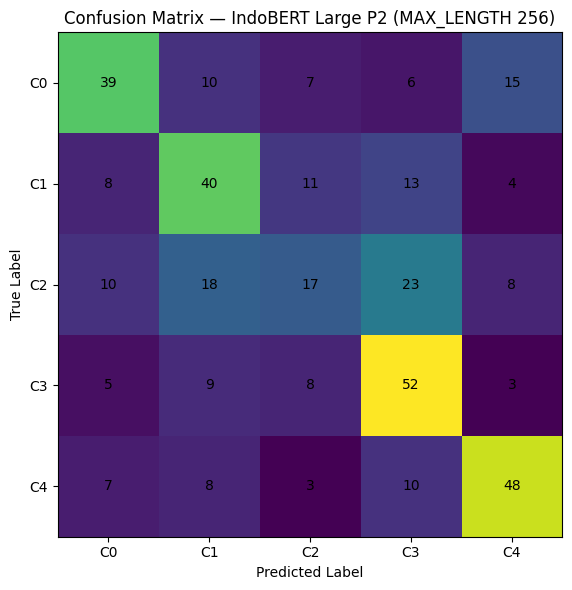


Confusion matrix figure saved to:
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256/confusion_matrix.png


In [27]:
# ============================================================
# CELL 17 — CONFUSION MATRIX + HEATMAP
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("=" * 70)
print("FINAL CONFUSION MATRIX")
print("=" * 70)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3, 4]
)

labels_text = ["C0", "C1", "C2", "C3", "C4"]

cm_df = pd.DataFrame(
    cm,
    index=labels_text,
    columns=labels_text
)

print("\nConfusion Matrix:")
display(cm_df)

# ============================================================
# SAVE CSV
# ============================================================

cm_df.to_csv(
    CONFUSION_MATRIX_PATH
)

print("\nConfusion matrix saved to:")
print(CONFUSION_MATRIX_PATH)

# ============================================================
# HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm)

ax.set_xticks(range(len(labels_text)))
ax.set_yticks(range(len(labels_text)))

ax.set_xticklabels(labels_text)
ax.set_yticklabels(labels_text)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(
    "Confusion Matrix — IndoBERT Large P2 (MAX_LENGTH 256)"
)

# Tampilkan angka pada setiap sel
for i in range(len(labels_text)):
    for j in range(len(labels_text)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

CONFUSION_MATRIX_FIGURE_PATH = os.path.join(
    FINAL_RESULTS_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix figure saved to:")
print(CONFUSION_MATRIX_FIGURE_PATH)

In [31]:
# ============================================================
# CELL 18 — ERROR ANALYSIS
# Fokus: C2 → C3
# ============================================================

print("=" * 70)
print("ERROR ANALYSIS — C2 → C3")
print("=" * 70)

# Ambil komentar yang label aslinya C2 tetapi diprediksi C3
c2_to_c3 = test_predictions_df[
    (test_predictions_df["true_label"] == "C2") &
    (test_predictions_df["predicted_label"] == "C3")
].copy()

print(f"\nJumlah C2 → C3 : {len(c2_to_c3)}")

# Tampilkan komentar
display(
    c2_to_c3[
        [TEXT_COL, "true_label", "predicted_label"]
    ].reset_index(drop=True)
)

ERROR ANALYSIS — C2 → C3

Jumlah C2 → C3 : 23


,Komentar_preprocessed,true_label,predicted_label
0,parcok saat ini tempat berkumpulnya para mafia...,C2,C3
1,setuju sekali mas bro 👍 kita dukung dan satuka...,C2,C3
2,tidak percaya sama raja panci gongor kentut ba...,C2,C3
3,"tonton full dulu.. kebiasaan kadrun, telan men...",C2,C3
4,seperti nya ini kelompok koruptor semua 🤭🤔,C2,C3
5,"alhamduliillah, akhirnya terbongkar siapa peng...",C2,C3
6,"bung pigai ,mantap, libas terus perusak demokr...",C2,C3
7,"matur nuwun atas dukungannya mas bro, kita duk...",C2,C3
8,gibran penipu seperti jokowi !,C2,C3
9,​ orang kampung pura pura bodoh tidak tahu nya...,C2,C3


In [32]:
# ============================================================
# ERROR ANALYSIS — SEMUA MISCLASSIFICATION
# ============================================================

errors_df = test_predictions_df[
    test_predictions_df["true_label"] !=
    test_predictions_df["predicted_label"]
].copy()

print("=" * 70)
print("ALL MISCLASSIFICATIONS")
print("=" * 70)

print(f"Total test       : {len(test_predictions_df)}")
print(f"Total salah      : {len(errors_df)}")
print(
    f"Error rate       : "
    f"{len(errors_df) / len(test_predictions_df):.2%}"
)

# ============================================================
# POLA KESALAHAN
# ============================================================

error_pairs = (
    errors_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nPola kesalahan:")
display(error_pairs)

ALL MISCLASSIFICATIONS
Total test       : 382
Total salah      : 186
Error rate       : 48.69%

Pola kesalahan:


,true_label,predicted_label,count
10,C2,C3,23
9,C2,C1,18
3,C0,C4,15
6,C1,C3,13
5,C1,C2,11
8,C2,C0,10
0,C0,C1,10
19,C4,C3,10
13,C3,C1,9
11,C2,C4,8


In [28]:
print("FINAL_RESULTS_DIR:")
print(FINAL_RESULTS_DIR)

print("\nIsi folder:")
print(os.listdir(FINAL_RESULTS_DIR))

FINAL_RESULTS_DIR:
/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256

Isi folder:
['final_metrics.csv', 'test_predictions.csv', 'classification_report.csv', 'confusion_matrix.csv', 'confusion_matrix.png']


In [29]:
import os

path = "/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256"

print("Folder exists :", os.path.exists(path))
print("\nIsi folder:")

for file in os.listdir(path):
    full_path = os.path.join(path, file)
    print(
        file,
        "→",
        round(os.path.getsize(full_path) / 1024, 2),
        "KB"
    )

Folder exists : True

Isi folder:
final_metrics.csv → 0.3 KB
test_predictions.csv → 66.73 KB
classification_report.csv → 0.56 KB
confusion_matrix.csv → 0.09 KB
confusion_matrix.png → 94.98 KB


In [34]:
!pwd
!git remote -v
!git status

/content
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [35]:
!git clone https://github.com/shefiramarizcha62-sudo/TA.git /content/TA

Cloning into '/content/TA'...


In [36]:
%cd /content/TA

/content/TA


In [37]:
!pwd
!ls -la

/content/TA
total 12
drwxr-xr-x 3 root root 4096 Aug 30 23:10 .
drwxr-xr-x 1 root root 4096 Aug 30 23:10 ..
drwxr-xr-x 7 root root 4096 Aug 30 23:10 .git


In [ ]:
!mkdir -p notebooks
!mkdir -p results/final_large_p2_max256

In [38]:
# ============================================================
# SETUP REPOSITORY TA
# ============================================================

%cd /content/TA

# Buat folder
!mkdir -p notebooks
!mkdir -p results/final_large_p2_max256

# Lokasi hasil final di Google Drive
DRIVE_FINAL="/content/drive/MyDrive/TA EKUIVALENSI/Revisi 27 08/results/final_large_p2_max256"

# Copy hasil evaluasi saja
!cp "$DRIVE_FINAL/final_metrics.csv" results/final_large_p2_max256/
!cp "$DRIVE_FINAL/test_predictions.csv" results/final_large_p2_max256/
!cp "$DRIVE_FINAL/classification_report.csv" results/final_large_p2_max256/
!cp "$DRIVE_FINAL/confusion_matrix.csv" results/final_large_p2_max256/
!cp "$DRIVE_FINAL/confusion_matrix.png" results/final_large_p2_max256/

# Cek
print("=" * 60)
print("FILES IN REPOSITORY")
print("=" * 60)

!find . -maxdepth 4 -type f | sort

/content/TA
FILES IN REPOSITORY
./.git/config
./.git/description
./.git/HEAD
./.git/hooks/applypatch-msg.sample
./.git/hooks/commit-msg.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/post-update.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/pre-commit.sample
./.git/hooks/pre-merge-commit.sample
./.git/hooks/prepare-commit-msg.sample
./.git/hooks/pre-push.sample
./.git/hooks/pre-rebase.sample
./.git/hooks/pre-receive.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/update.sample
./.git/info/exclude
./results/final_large_p2_max256/classification_report.csv
./results/final_large_p2_max256/confusion_matrix.csv
./results/final_large_p2_max256/confusion_matrix.png
./results/final_large_p2_max256/final_metrics.csv
./results/final_large_p2_max256/test_predictions.csv


In [39]:
!find /content -maxdepth 3 -name "*.ipynb" -type f